# 03. 접수 수요 시간대/요일 분석

접수일시 기준 시간대별, 요일별, 요일 X 시간대별 요청 수요를 분석한다.


In [8]:
import json
import platform
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# 한글 폰트 설정
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

# 프로젝트 루트 설정
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

# 서울 자치구 지도 데이터 로드
map_path = project_root / "data" / "raw" / "seoul_municipalities_geo_simple.json"

with open(map_path, encoding="utf-8") as map_file:
    seoul_map = json.load(map_file)

In [9]:
df_request = pd.read_csv(
    '../data/processed/서울시설공단_장애인콜택시 접수일시_월주차_파생컬럼_20251231.csv',
    parse_dates=['접수일시', '접수일자']
)

df_request.info()
df_request.head()


<class 'pandas.DataFrame'>
RangeIndex: 1722490 entries, 0 to 1722489
Data columns (total 22 columns):
 #   Column   Dtype         
---  ------   -----         
 0   접수일시     datetime64[us]
 1   예정일시     str           
 2   배차일시     str           
 3   승차일시     str           
 4   하차일시     str           
 5   취소일시     str           
 6   출발구      str           
 7   출발동      str           
 8   목적구      str           
 9   목적동      str           
 10  이용목적     str           
 11  요금       float64       
 12  승차거리     int64         
 13  차량구분     str           
 14  장애유형     str           
 15  접수일자     datetime64[us]
 16  접수시간     str           
 17  접수시간대    int64         
 18  접수요일     str           
 19  접수월      str           
 20  접수ISO주차  int64         
 21  접수월주차    str           
dtypes: datetime64[us](2), float64(1), int64(3), str(16)
memory usage: 289.1 MB


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,...,승차거리,차량구분,장애유형,접수일자,접수시간,접수시간대,접수요일,접수월,접수ISO주차,접수월주차
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,...,17667,특장차,지체,2025-01-01,00:01:26,0,수요일,2025-01,1,2025-01-1주차
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaN,NaN,2025-01-01 00:21:15.000,영등포구,여의동,강서구,화곡제6동,...,0,특장차,뇌병,2025-01-01,00:03:10,0,수요일,2025-01,1,2025-01-1주차
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,...,2910,특장차,뇌병,2025-01-01,00:03:31,0,수요일,2025-01,1,2025-01-1주차
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,...,10421,특장차,지체,2025-01-01,00:03:40,0,수요일,2025-01,1,2025-01-1주차
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,...,11943,특장차,지체,2025-01-01,00:04:15,0,수요일,2025-01,1,2025-01-1주차


### 시간대별 접수 수요

In [10]:
hourly_request_count = (
    df_request
    .dropna(subset=['접수시간대'])
    .groupby('접수시간대')
    .size()
    .reindex(range(24), fill_value=0)
    .reset_index(name='접수건수')
)

hourly_request_count['시간대'] = hourly_request_count['접수시간대'].map(
    lambda x: f'{int(x):02d}시'
)

display(hourly_request_count)

,접수시간대,접수건수,시간대
0,0,2186,00시
1,1,1330,01시
2,2,2889,02시
3,3,6644,03시
4,4,20267,04시
5,5,22971,05시
6,6,29337,06시
7,7,123665,07시
8,8,143766,08시
9,9,111418,09시


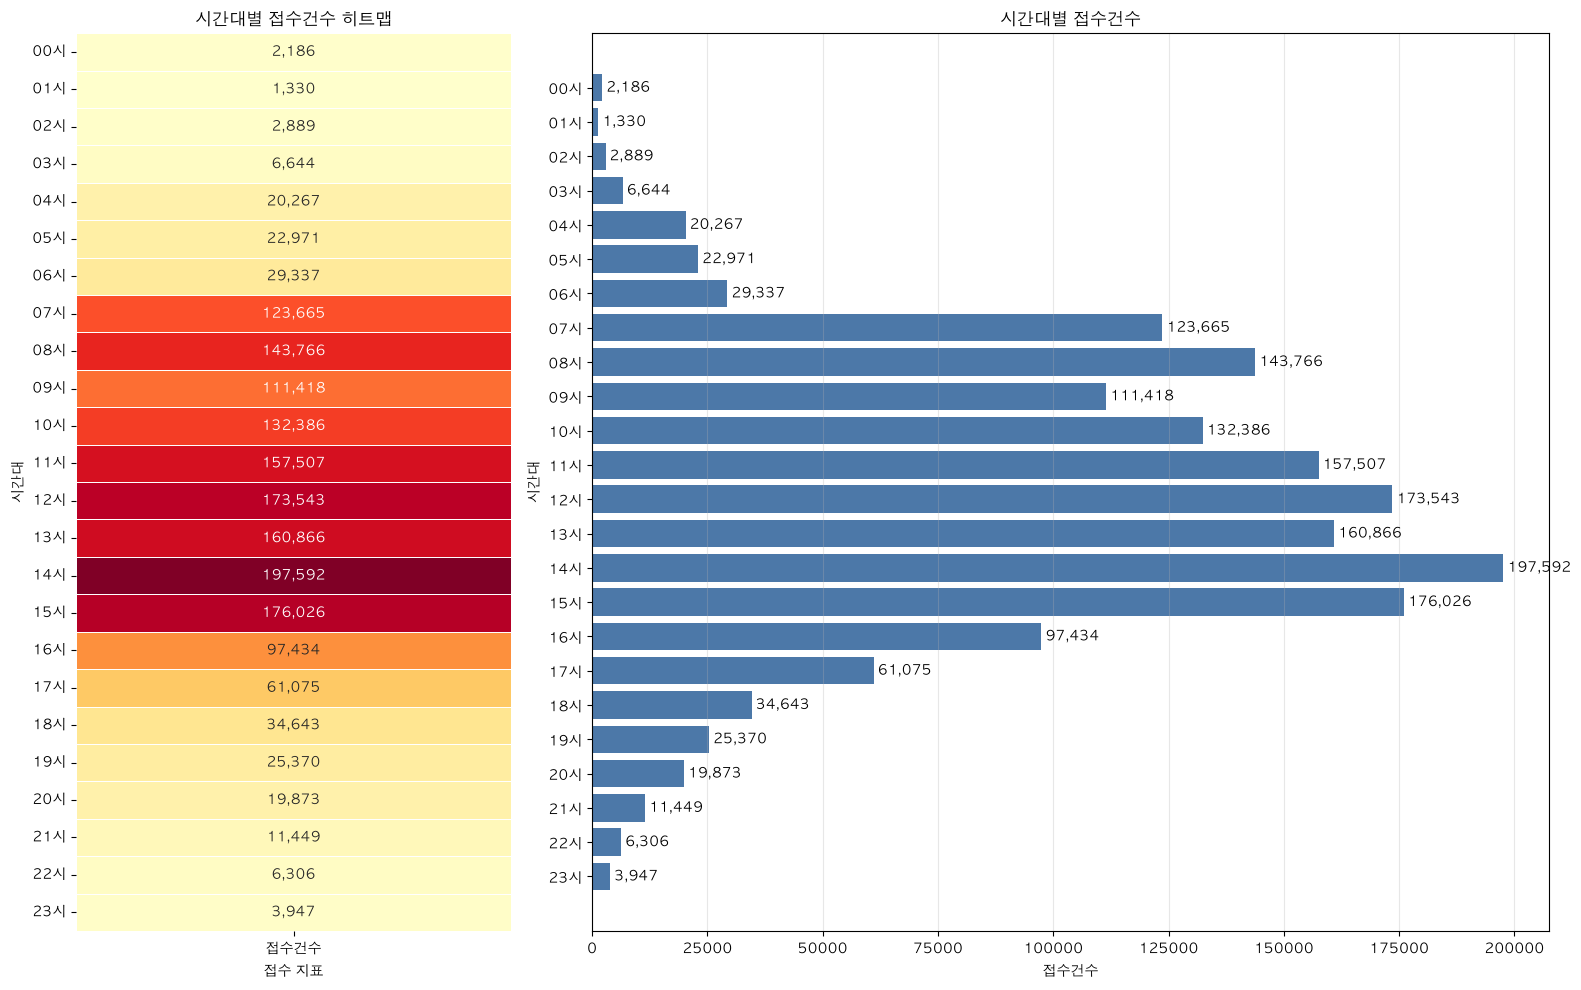

In [11]:
hourly_request_count = (
    df_request
    .dropna(subset=['접수시간대'])
    .groupby('접수시간대')
    .size()
    .reindex(range(24), fill_value=0)
    .reset_index(name='접수건수')
)

hourly_request_count['시간대'] = hourly_request_count['접수시간대'].map(
    lambda x: f'{int(x):02d}시'
)

hourly_heatmap_data = hourly_request_count.set_index('시간대')[['접수건수']]

fig, (ax_heatmap, ax_bar) = plt.subplots(
    1,
    2,
    figsize=(16, 10),
    gridspec_kw={'width_ratios': [1, 2.2]}
)

sns.heatmap(
    hourly_heatmap_data,
    ax=ax_heatmap,
    cmap='YlOrRd',
    annot=True,
    fmt=',.0f',
    linewidths=0.5,
    cbar=False
)

ax_heatmap.set_title('시간대별 접수건수 히트맵')
ax_heatmap.set_xlabel('접수 지표')
ax_heatmap.set_ylabel('시간대')
ax_heatmap.tick_params(axis='y', rotation=0)

ax_bar.barh(
    hourly_request_count['시간대'],
    hourly_request_count['접수건수'],
    color='#4c78a8'
)

ax_bar.invert_yaxis()
ax_bar.set_title('시간대별 접수건수')
ax_bar.set_xlabel('접수건수')
ax_bar.set_ylabel('시간대')
ax_bar.grid(axis='x', alpha=0.3)

for index, value in enumerate(hourly_request_count['접수건수']):
    ax_bar.text(
        value,
        index,
        f' {value:,.0f}',
        va='center'
    )

plt.tight_layout()
plt.show()

### 요일별 접수 수요

In [12]:
weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']

weekday_request_count = (
    df_request
    .dropna(subset=['접수요일'])
    .groupby('접수요일')
    .size()
    .reindex(weekday_order, fill_value=0)
    .reset_index(name='접수건수')
)

weekday_request_count['접수비중(%)'] = (
    weekday_request_count['접수건수']
    / weekday_request_count['접수건수'].sum()
    * 100
)

display(weekday_request_count)

,접수요일,접수건수,접수비중(%)
0,월요일,296870,17.234933
1,화요일,296271,17.200158
2,수요일,306416,17.789131
3,목요일,290893,16.887935
4,금요일,287647,16.699487
5,토요일,126327,7.333976
6,일요일,118066,6.854379


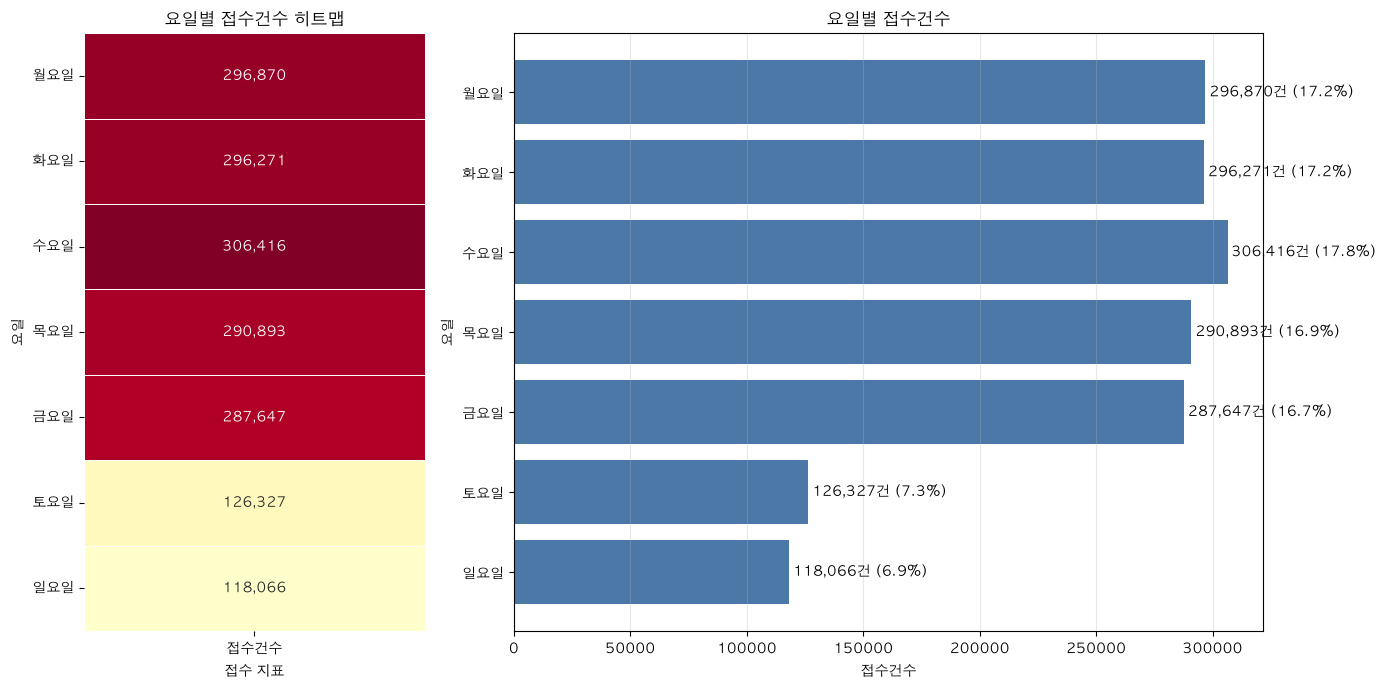

In [13]:
weekday_heatmap_data = weekday_request_count.set_index('접수요일')[['접수건수']]

fig, (ax_heatmap, ax_bar) = plt.subplots(
    1,
    2,
    figsize=(14, 7),
    gridspec_kw={'width_ratios': [1, 2.2]}
)

sns.heatmap(
    weekday_heatmap_data,
    ax=ax_heatmap,
    cmap='YlOrRd',
    annot=True,
    fmt=',.0f',
    linewidths=0.5,
    cbar=False
)

ax_heatmap.set_title('요일별 접수건수 히트맵')
ax_heatmap.set_xlabel('접수 지표')
ax_heatmap.set_ylabel('요일')
ax_heatmap.tick_params(axis='y', rotation=0)

ax_bar.barh(
    weekday_request_count['접수요일'],
    weekday_request_count['접수건수'],
    color='#4c78a8'
)

ax_bar.invert_yaxis()
ax_bar.set_title('요일별 접수건수')
ax_bar.set_xlabel('접수건수')
ax_bar.set_ylabel('요일')
ax_bar.grid(axis='x', alpha=0.3)

for index, value in enumerate(weekday_request_count['접수건수']):
    rate = weekday_request_count.loc[index, '접수비중(%)']
    ax_bar.text(
        value,
        index,
        f' {value:,.0f}건 ({rate:.1f}%)',
        va='center'
    )

plt.tight_layout()
plt.show()

### 요일 X 시간대별 접수 수요

In [14]:
weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']

request_weekday_hour_pivot = (
    df_request
    .dropna(subset=['접수요일', '접수시간대'])
    .pivot_table(
        index='접수요일',
        columns='접수시간대',
        values='접수일시',
        aggfunc='count',
        fill_value=0
    )
    .reindex(weekday_order)
)

request_weekday_hour_pivot.columns = [
    f'{int(hour):02d}시' for hour in request_weekday_hour_pivot.columns
]

request_weekday_hour_pivot

,00시,01시,02시,03시,04시,05시,06시,07시,08시,09시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
접수요일,,,,,,,,,,,,,,,,,,,,,
월요일,254,151,378,1388,4010,4396,5343,23753,24509,16979,...,35854,32290,16859,10736,5335,3444,2570,1587,833,467
화요일,235,171,501,890,3483,4128,5604,22699,24699,17301,...,36083,31495,16649,10279,5245,3779,2992,1733,866,530
수요일,309,178,373,1444,3940,4393,5408,23314,25320,18288,...,37002,33300,17276,10140,5226,3590,3424,1656,936,539
목요일,273,197,513,856,3442,4065,5400,22128,24735,17194,...,34417,30910,16305,10264,5200,3939,3017,1844,911,583
금요일,287,170,416,1328,3633,4283,4969,18936,21113,18718,...,35134,30094,16198,9475,5481,3932,3228,1953,1126,747
토요일,439,253,513,464,1396,1051,1782,4701,9192,11589,...,9423,9921,7874,5266,4146,3504,2651,1572,977,671
일요일,389,210,195,274,363,655,831,8134,14198,11349,...,9679,8016,6273,4915,4010,3182,1991,1104,657,410


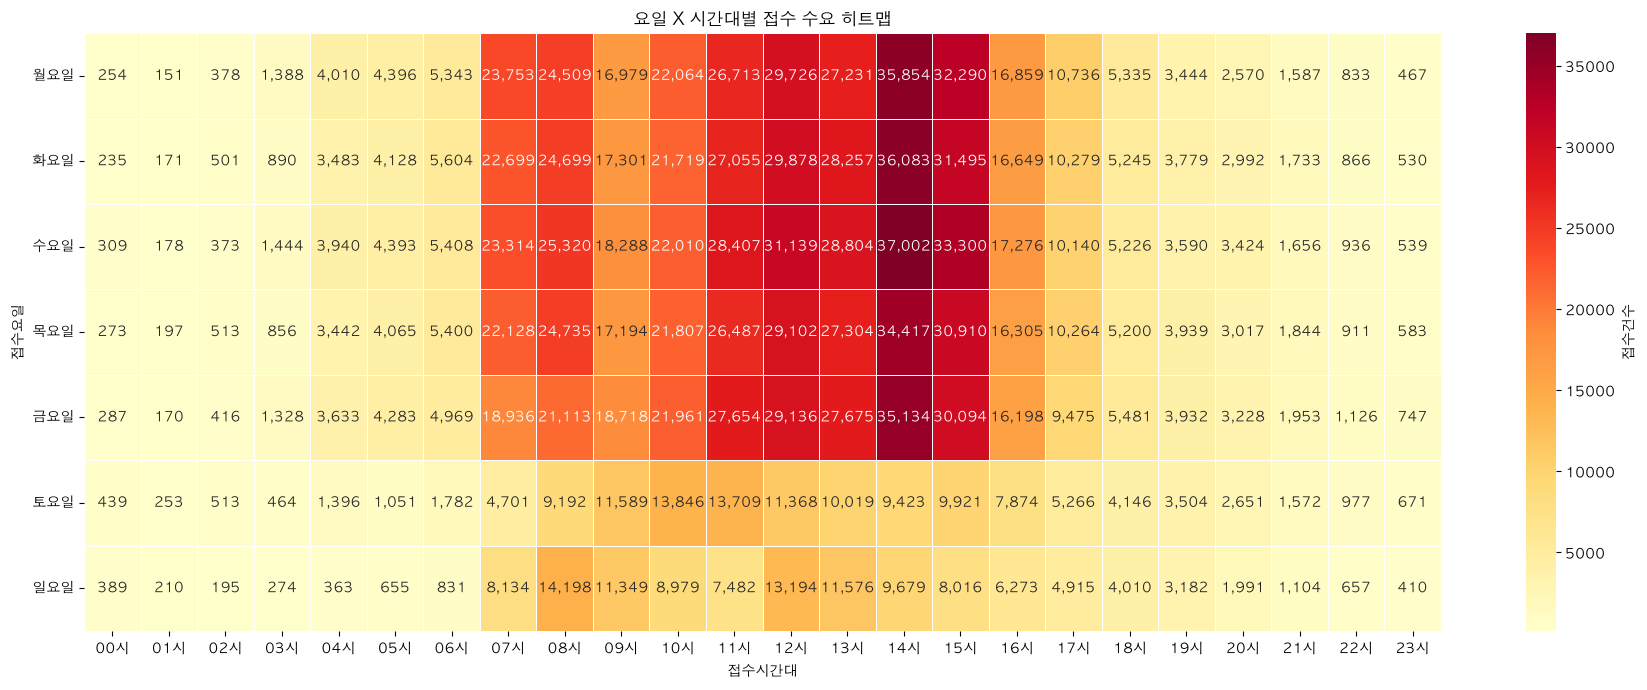

In [15]:
plt.figure(figsize=(18, 7))

sns.heatmap(
    request_weekday_hour_pivot,
    cmap='YlOrRd',
    annot=True,
    fmt=',.0f',
    linewidths=0.5,
    cbar_kws={'label': '접수건수'}
)

plt.title('요일 X 시간대별 접수 수요 히트맵')
plt.xlabel('접수시간대')
plt.ylabel('접수요일')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()